
# DAT550 Final Project

Music to note transcriptor

# Summary

In this stage all files will be read, transformed and converted to its respective wave file.
Initially substantial features for each wave filewill be extracted and later on saved for ML training.

## Final project objective
To find the most suitable music notation model and evaluate different approaches.

## Data Preprocessing
- To choose among different feature extraction algorithms

## Algorithms to use

- [X] CNN Convolutional Neural Network
- [X] Transformers (From HugginFace)
- [ ] RNN-LSTM (Maybe)
- [ ] Classic classification approach
    - Random Forest
    - Naive Bayes 
 - MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
     - Dataset Splitting
     - MidiSplit(filepath, chunks_per_sec, )
     - MidiLabel(chunk,number_of_tracks ) => Returns a vector with given notes per chunk
     MIDI_FILE [1 Chunk] -> [Wave]  -> Guess the most suitable note [B] 
         - Track 1 - Piano  -> A -> Intensity[1] - Pitch 
         - Track 2 - Drums  -> B -> Intensity [255]
         - TRack 3 - Guitar -> A -> Intensity
     Initial labels -- GroundTruth[] Training outpus 
     
     Feature Extraction - Average -> A
     
 - MIDI to Wave 
 - Wave to Spectrogram [Feature vector]
     - Feature Extraction
 - Test / Train model
 - Output Note per time [Second or millisecond] -> Append to a list
 - [- - - - - - - - - - - - - - - - - - - - - - - A - - - - B - - - - - A A A A A A A A G ]
 - Vector to MIDI
 - MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
 - Evaluation
     - [X] MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
     - [X] MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
 
 - Transform the output of a vector back to MIDI
 
 


# Goal
- [X] Pretrained [Wav2Vec](https://huggingface.co/transformers/model_doc/wav2vec2.html) 
    - Baseline, From a given pretrained model, feed a set of expected features and evaluate its accuracy
- [X] Bootstrap
    - Based on different datasets:
        - MIDI poliphonic Sound files [Training model]
            - Data preprocessing +  CNN - 
        - MIDI poliphonic Sound files [Test model]
        - Complex melodies -- [Test model]
# Training
- Labeling the data - Midi notes extraction
- Song decomposition
- Spectrogram feature extraction
- CNN Model training

To try different Deep learning methods (Neural Network models) to evaluate the most accurate.


# Tasks
## Basic
### Person 1 [Asahi]
1 - Create function to open a MIDI File splitted in chunks
2 - Create function to extract notes per MIDI file
### Person 2 [Shaon]
3 - Create function to Convert MIDI to Wave
4 - Model performance evaluation (Loss function)
8 - Wave2Vec HuggingFace - 
### Person 3  [Lucas]
5 - Report
6 - Cloud notebook deployment
### Person 4 [Tim]
6 - Basic Feature extraction (Wave2Spectrogram)
7 - Advanced Feature extraction functions


### Next meeting: Monday 29 APR. Maybe earlier

## Advanced

5 - Classical model evaluations
6 - CNN/Transformer





# Data Preprocessing

### Midi to note

In [1]:
import os

data_path = os.path.join('..','data','split_midi') 
mid_file = str(os.path.join(data_path,'song1._100.mid'))
MIDI_SOUND_FONT = 'C:\\development\\repos\\Uni\\dat550-2021\\DeepWhiners\\198_Yamaha_SY1_piano.sf2'
MIDI_SOUND_FONT = 'C:\\MIDI\\SoundFonts\\MuseScore_General.sf2'

In [2]:
import librosa
from mido import MidiFile
from mido.messages.messages import Message

mid = MidiFile(mid_file, clip=True)
#midi_file = librosa.load(str(mid_file))
#help(mid.tracks[0][0])
notes = []
for msg in mid.tracks[0]:
    if type(msg) is Message: 
        notes.append(msg.note)
#print(notes)
librosa.midi_to_note(notes, octave=True, cents=False, key='C:maj', unicode=True)

['G4', 'C4', 'E5', 'C4']

In [3]:
len(mid.tracks)

1

### Pretty midi

**load data in prettyMidi format**

In [4]:
# https://craffel.github.io/pretty-midi/
import pretty_midi
# Load MIDI file into PrettyMIDI object
midi_data = pretty_midi.PrettyMIDI(mid_file)
# Print an empirical estimate of its global tempo
#print(midi_data.estimate_tempo()) # works only for more than one note


**synthesize**

In [5]:
# Synthesize the resulting MIDI data using sine waves
sine_synth = midi_data.synthesize()

**visualize**

128 13 (128, 13)


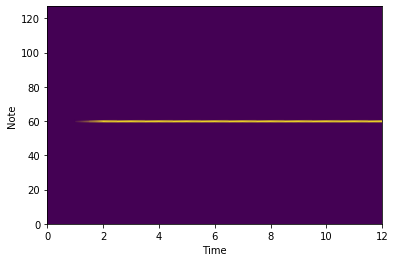

In [6]:
piano_roll = midi_data.get_piano_roll()

import numpy as np
import matplotlib.pyplot as plt
print(np.array(piano_roll).shape[0], np.array(piano_roll).shape[1], piano_roll.shape)
plt.pcolormesh(np.arange(piano_roll.shape[1]), np.arange(piano_roll.shape[0]), piano_roll, shading='gouraud')
plt.ylabel('Note')
plt.xlabel('Time')
plt.show()

**save**

In [7]:
midi_data.write("example_output.mid")

### Midi to Wav
Importat  to download and add fluidsynth path to the environment variable
https://github.com/FluidSynth/fluidsynth/releases/tag/v2.1.8

```bash
pip install midi2audio

```

In [8]:
# https://github.com/bzamecnik/midi2audio
import IPython
from midi2audio import FluidSynth

fs = FluidSynth(sound_font=MIDI_SOUND_FONT)
wave_file = 'output.wav'
fs.midi_to_audio(mid_file, wave_file)
IPython.display.Audio(wave_file)

### Spectograms

In [9]:
import numpy as np
from pydub import AudioSegment
wave = AudioSegment.from_wav(wave_file)
from_30s_to_60s = wave[30000:60000]
raw = np.array(from_30s_to_60s.get_array_of_samples())
#from_30s_to_60s

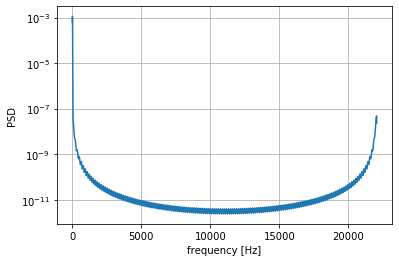

In [10]:
# From scipy.signal.spectrogram docs
from scipy import signal
from scipy.fft import fftshift
from scipy.io import wavfile
import matplotlib.pyplot as plt

samplingFrequency, signalData = wavfile.read(wave_file)
f, Pper_spec = signal.periodogram(signalData[:,0], samplingFrequency, 'flattop', scaling='spectrum')

plt.semilogy(f, Pper_spec)
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD')
plt.grid()
plt.show()

c:\development\software\python 3.8.1\lib\site-packages\librosa\filters.py:238: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  warnings.warn(


[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

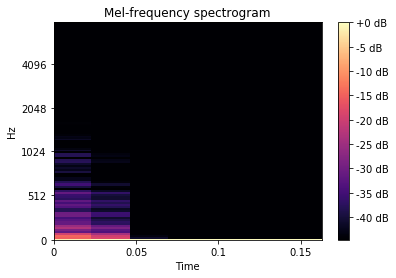

In [11]:
#https://librosa.org/doc/latest/generated/librosa.feature.melspectrogram.html
import librosa.display
y, sr = librosa.load(wave_file)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=22050)

fig, ax = plt.subplots()
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

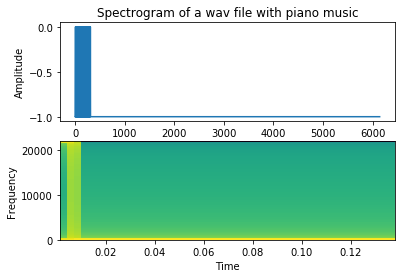

In [12]:
# https://pythontic.com/visualization/signals/spectrogram
#import the pyplot and wavfile modules 
import matplotlib.pyplot as plot

from scipy.io import wavfile

# Read the wav file (mono)
samplingFrequency, signalData = wavfile.read(wave_file)

# Plot the signal read from wav file
plot.subplot(211)
plot.title('Spectrogram of a wav file with piano music')

plot.plot(signalData[:, 0][:44100])
plot.xlabel('Sample')
plot.ylabel('Amplitude')


plot.subplot(212)
Spec, f, t, img = plot.specgram(signalData[:, 0][:44100],Fs=samplingFrequency) # plot one channel, first second
plot.xlabel('Time')
plot.ylabel('Frequency')
plot.show()

# Postprocessing
### e.g. abc-notation to sheet music conversion

# Feature extraction

Melspectrogram

(128, 733)


c:\development\software\python 3.8.1\lib\site-packages\librosa\filters.py:238: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  warnings.warn(


[Text(0.5, 1.0, 'log-power Mel-frequency spectrogram')]

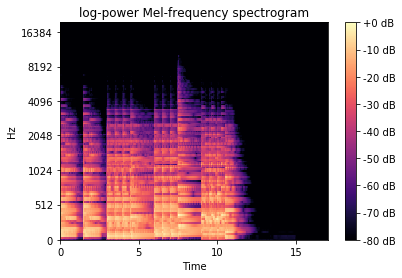

In [13]:
from feature_extraction import *
Mel_Spec, sample_rate = wav_to_melspec('example.wav', n_mels=128, max_freq=20000)

# plot just for visualization
print(Mel_Spec.shape)
fig, ax = plt.subplots()
img = librosa.display.specshow(Mel_Spec, x_axis='time', y_axis='mel', sr=sr, fmax=20000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='log-power Mel-frequency spectrogram')

Mel-frequency cepstral coefficients (MFCCs)

(128, 733)


[Text(0.5, 1.0, 'MFCC')]

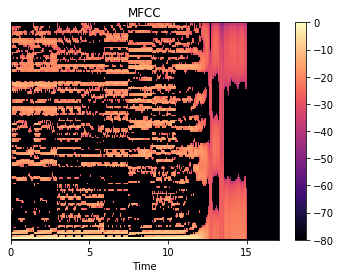

In [14]:
from feature_extraction import *
Mfcc, sample_rate = wav_to_mfcc('example.wav', n_mfcc=128, max_freq=20000)

# plot just for visualization
print(Mfcc.shape)
fig, ax = plt.subplots()
img = librosa.display.specshow(Mfcc, x_axis='time', ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='MFCC')

constant-Q transform

(88, 733)


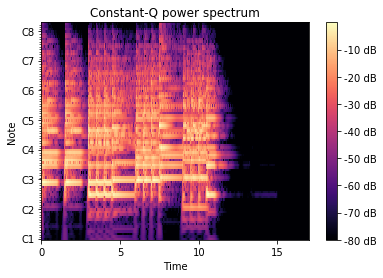

In [25]:
from feature_extraction import *
Cqt, sample_rate = wav_to_cq('example.wav', n_bins=88)

# plot just for visualization
print(Cqt.shape)
fig, ax = plt.subplots()
img = librosa.display.specshow(Cqt, sr=sr, x_axis='time', y_axis='cqt_note', ax=ax)

ax.set_title('Constant-Q power spectrum')
fig.colorbar(img, ax=ax, format="%+2.0f dB")

### Dimensionality reduction

PCA

In [79]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50) 
pca_ms = pca.fit_transform(Mel_Spec.T)
print(pca.explained_variance_ratio_)

pca = PCA(n_components=50) 
pca_mfcc = pca.fit_transform(Mfcc.T)
print(pca.explained_variance_ratio_)

pca = PCA(n_components=50) 
pca_cqt = pca.fit_transform(Cqt.T)
print(pca.explained_variance_ratio_)

[9.10371184e-01 2.72841211e-02 1.41780963e-02 1.03820805e-02
 8.25854205e-03 4.92694695e-03 3.90671706e-03 3.37514072e-03
 2.12648464e-03 1.87819765e-03 1.61123974e-03 1.11475366e-03
 1.02651643e-03 8.97095131e-04 8.62518209e-04 5.70593693e-04
 5.41954127e-04 4.80961840e-04 4.06394596e-04 3.83653591e-04
 3.34130513e-04 3.19181185e-04 3.01353284e-04 2.88027077e-04
 2.82568042e-04 2.42681985e-04 2.32584542e-04 2.14120460e-04
 2.04828233e-04 1.96914465e-04 1.88368824e-04 1.73754364e-04
 1.56578113e-04 1.47583662e-04 1.32529065e-04 1.26060448e-04
 1.20871213e-04 1.14203554e-04 1.06588763e-04 1.05047184e-04
 9.38473095e-05 9.06986534e-05 7.68498358e-05 7.43768760e-05
 6.91681271e-05 6.44780957e-05 5.63809554e-05 5.48114840e-05
 5.14039675e-05 4.76396272e-05]
[0.15104334 0.12507187 0.10341348 0.08013671 0.06076798 0.04496304
 0.03867595 0.03448141 0.0273715  0.02278256 0.02100325 0.01794388
 0.01508334 0.01479801 0.01411979 0.01103915 0.00979751 0.00950682
 0.00854461 0.00776111 0.00710964 0

TSNE

In [92]:
from sklearn.manifold import TSNE

tsne_ms = TSNE(n_components=2).fit_transform(pca_ms)
tsne_mfcc = TSNE(n_components=2).fit_transform(pca_mfcc)
tsne_cqt = TSNE(n_components=2).fit_transform(pca_cqt)

tsne_ms.shape, tsne_mfcc.shape, tsne_cqt.shape

((733, 2), (733, 2), (733, 2))

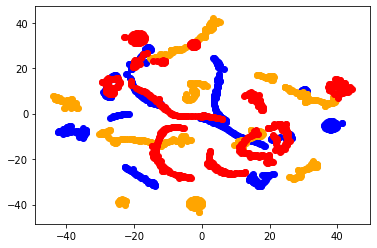

In [93]:
plt.scatter(tsne_ms.T[0], tsne_ms.T[1], color="blue")
plt.scatter(tsne_mfcc.T[0], tsne_mfcc.T[1], color="orange")
plt.scatter(tsne_cqt.T[0], tsne_cqt.T[1], color="red")

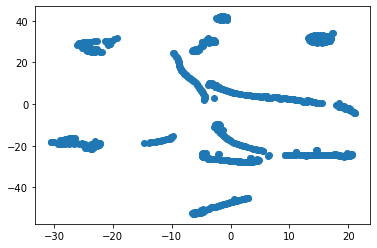

In [90]:
plt.scatter(tsne_ms.T[0], tsne_ms.T[1])

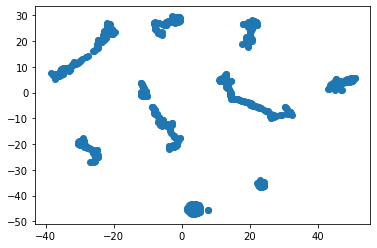

In [88]:
plt.scatter(tsne_mfcc.T[0], tsne_mfcc.T[1])

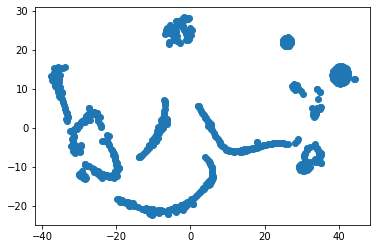

In [89]:
plt.scatter(tsne_cqt.T[0], tsne_cqt.T[1])